In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from jpype.types import JInt, JArray, JString
from typing import List, Tuple

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
GreedyAlgorithms = jpype.JClass("utils.greedy_algorithms.GreedyAlgorithms")
Segment = jpype.JClass("utils.greedy_algorithms.GreedyAlgorithms$Segment")
Request = jpype.JClass("utils.greedy_algorithms.GreedyAlgorithms$Request")
MaxNonOverlappingSegments = jpype.JClass("utils.greedy_algorithms.GreedyAlgorithms$MaxNonOverlappingSegments")
MaxRequests = jpype.JClass("utils.greedy_algorithms.GreedyAlgorithms$MaxRequests")
MinCoverage = jpype.JClass("utils.greedy_algorithms.GreedyAlgorithms$MinCoverage")

ArrayList = jpype.JClass("java.util.ArrayList")
JavaList = jpype.JClass("java.util.List")

In [2]:
def generate_random_segments(n: int, max_coord: int = 100) -> JavaList:
    segments = ArrayList()
    for _ in range(n):
        start = random.randint(0, max_coord - 1)
        end = random.randint(start + 1, max_coord)
        segments.add(Segment(start, end))
    return segments

def generate_random_requests(n: int, max_time: int = 100) -> JavaList:
    requests = ArrayList()
    for _ in range(n):
        start = random.randint(0, max_time - 1)
        end = random.randint(start + 1, max_time)
        requests.add(Request(start, end))
    return requests

def test_task1(n_values: List[int], iterations: int = 10):
    results = []
    
    for n in n_values:
        print(f"\nТестирование задачи 1 для n = {n}")
        times = []
        counts = []
        
        for _ in range(iterations):
            segments = generate_random_segments(n)
            algorithm = MaxNonOverlappingSegments()
            result = algorithm.findMaxNonOverlapping(segments)
            
            times.append(result.executionTime)
            counts.append(len(result.result))
        
        results.append({
            'n': n,
            'mean_time': np.mean(times),
            'std_time': np.std(times),
            'mean_count': np.mean(counts),
            'std_count': np.std(counts)
        })
    
    return results

def test_task2(n_values: List[int], iterations: int = 10):
    results = []
    
    for n in n_values:
        print(f"\nТестирование задачи 2 для n = {n}")
        times = []
        counts = []
        
        for _ in range(iterations):
            requests = generate_random_requests(n)
            algorithm = MaxRequests()
            result = algorithm.findMaxRequests(requests)
            
            times.append(result.executionTime)
            counts.append(len(result.result))
        
        results.append({
            'n': n,
            'mean_time': np.mean(times),
            'std_time': np.std(times),
            'mean_count': np.mean(counts),
            'std_count': np.std(counts)
        })
    
    return results

def test_task3(n_values: List[int], iterations: int = 10):
    results = []
    L = 0
    R = 100
    
    for n in n_values:
        print(f"\nТестирование задачи 3 для n = {n}")
        times = []
        counts = []
        
        for _ in range(iterations):
            segments = generate_random_segments(n, R)
            algorithm = MinCoverage()
            result = algorithm.findMinCoverage(segments, L, R)
            
            times.append(result.executionTime)
            counts.append(len(result.result))
        
        results.append({
            'n': n,
            'mean_time': np.mean(times),
            'std_time': np.std(times),
            'mean_count': np.mean(counts),
            'std_count': np.std(counts)
        })
    
    return results

def plot_results(results: List[dict], title: str, ylabel: str):
    n_values = [r['n'] for r in results]
    means = [r['mean_time'] for r in results]
    stds = [r['std_time'] for r in results]
    
    plt.figure(figsize=(10, 6))
    plt.errorbar(n_values, means, yerr=stds, fmt='o-')
    plt.xlabel('Количество элементов (n)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

def main():
    n_values = [10, 100, 1000, 10000]
    
    # Тестирование задачи 1
    print("Тестирование задачи 1: Максимальное подмножество непересекающихся отрезков")
    task1_results = test_task1(n_values)
    plot_results(task1_results, 
                "Время выполнения задачи 1", 
                "Среднее время выполнения (нс)")
    
    # Тестирование задачи 2
    print("\nТестирование задачи 2: Максимальное количество допустимых заявок")
    task2_results = test_task2(n_values)
    plot_results(task2_results, 
                "Время выполнения задачи 2", 
                "Среднее время выполнения (нс)")
    
    # Тестирование задачи 3
    print("\nТестирование задачи 3: Минимальное покрытие интервала отрезками")
    task3_results = test_task3(n_values)
    plot_results(task3_results, 
                "Время выполнения задачи 3", 
                "Среднее время выполнения (нс)")
    
    # Вывод результатов в таблицы
    print("\nРезультаты задачи 1:")
    df1 = pd.DataFrame(task1_results)
    print(df1.to_string(index=False))
    
    print("\nРезультаты задачи 2:")
    df2 = pd.DataFrame(task2_results)
    print(df2.to_string(index=False))
    
    print("\nРезультаты задачи 3:")
    df3 = pd.DataFrame(task3_results)
    print(df3.to_string(index=False))

Тестирование задачи 1: Максимальное подмножество непересекающихся отрезков

Тестирование задачи 1 для n = 10

Тестирование задачи 1 для n = 100

Тестирование задачи 1 для n = 1000

Тестирование задачи 1 для n = 10000


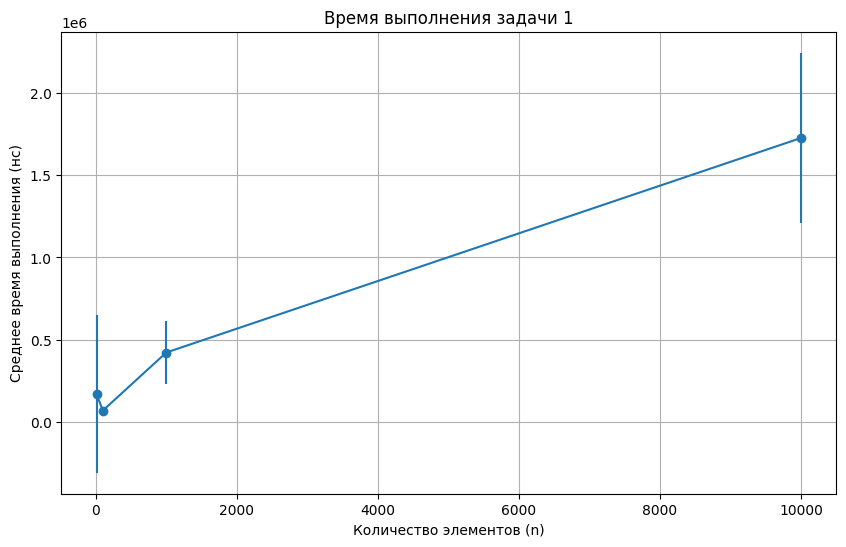


Тестирование задачи 2: Максимальное количество допустимых заявок

Тестирование задачи 2 для n = 10

Тестирование задачи 2 для n = 100

Тестирование задачи 2 для n = 1000

Тестирование задачи 2 для n = 10000


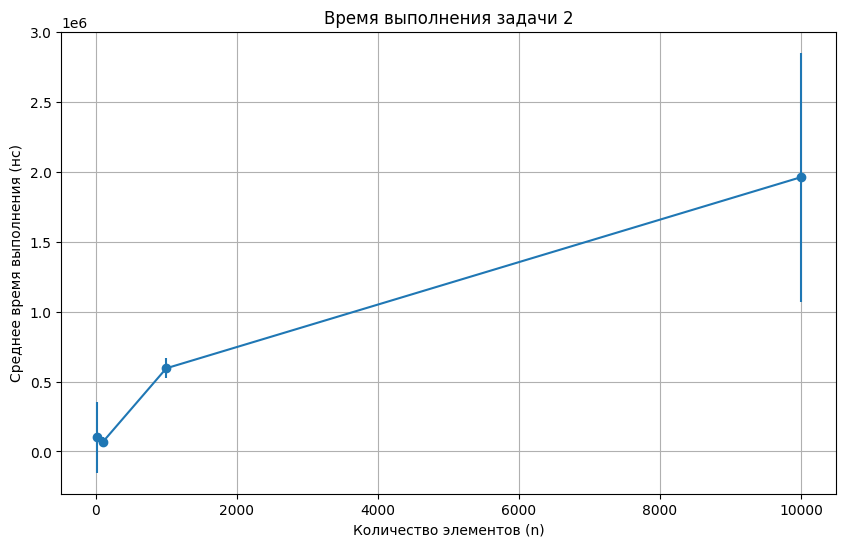


Тестирование задачи 3: Минимальное покрытие интервала отрезками

Тестирование задачи 3 для n = 10

Тестирование задачи 3 для n = 100

Тестирование задачи 3 для n = 1000

Тестирование задачи 3 для n = 10000


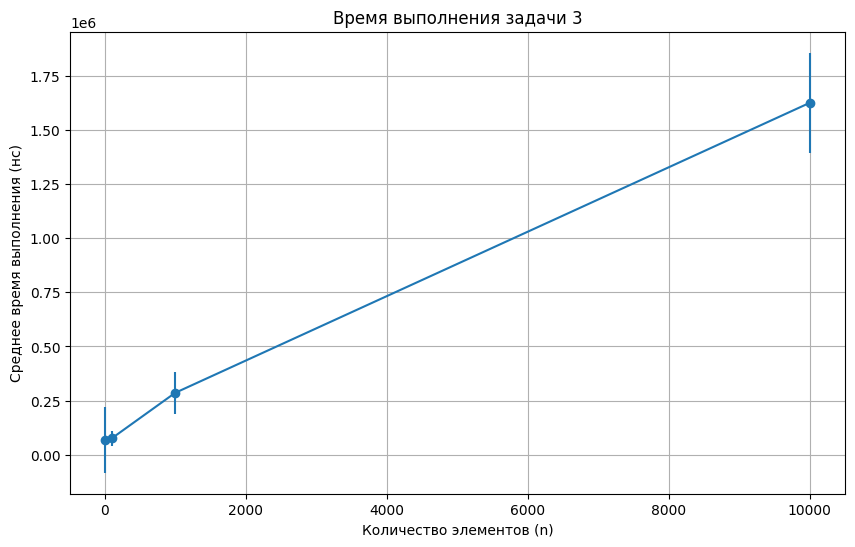


Результаты задачи 1:
    n  mean_time      std_time  mean_count  std_count
   10   169030.0 478563.619700         4.0   1.000000
  100    68610.0  23178.328240        14.1   1.700000
 1000   421720.0 190308.564179        42.2   2.441311
10000  1726670.0 518606.851189        87.8   2.039608

Результаты задачи 2:
    n  mean_time      std_time  mean_count  std_count
   10   101330.0 253461.429216         4.6   1.356466
  100    68310.0  36989.497158        13.4   1.562050
 1000   595380.0  71804.899554        41.9   4.011234
10000  1962970.0 890630.324040        86.4   2.497999

Результаты задачи 3:
    n  mean_time      std_time  mean_count  std_count
   10    67370.0 150899.834659         0.0   0.000000
  100    74830.0  35543.495889         1.4   1.200000
 1000   285360.0  96511.503978         2.0   0.000000
10000  1625940.0 231402.580798         1.3   0.458258


In [ ]:
main()